# 01 - EDA\n
\n
Exploracao inicial do dataset HVFHV usando Spark SQL. Todas as transformacoes analiticas ficam em `spark.sql()`; pandas aparece apenas depois de agregacoes pequenas para visualizacao.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

import matplotlib.pyplot as plt
import seaborn as sns

from _lib import build_spark, SEED, DATA_GLOB, LOOKUP_PATH

spark = build_spark('nyc-rideshare-eda')
sns.set_theme(style='whitegrid')

In [2]:
spark.read.parquet(DATA_GLOB).createOrReplaceTempView('trips_raw')
(spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(LOOKUP_PATH)
    .createOrReplaceTempView('taxi_zone_lookup'))

# Recorte temporal: Mar-Ago 2023 (6 meses). Dataset cobre Dez/2021-Ago/2023.
spark.sql("""
    CREATE OR REPLACE TEMPORARY VIEW trips_bronze AS
    SELECT * FROM trips_raw
    WHERE date >= '2023-03-01'
      AND date <  '2023-09-01'
""")

spark.sql('SELECT COUNT(*) AS total_rows FROM trips_bronze').show()


+----------+
|total_rows|
+----------+
| 116225448|
+----------+



In [3]:
spark.sql("""
SELECT
    MIN(date)  AS min_date,
    MAX(date)  AS max_date,
    COUNT(DISTINCT date) AS active_days,
    COUNT(*)   AS total_trips
FROM trips_bronze
""").show()

spark.sql("""
SELECT business, COUNT(*) AS trips,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
FROM trips_bronze
GROUP BY 1
ORDER BY 2 DESC
""").show()


+----------+----------+-----------+-----------+
|  min_date|  max_date|active_days|total_trips|
+----------+----------+-----------+-----------+
|2023-03-01|2023-08-31|        184|  116225448|
+----------+----------+-----------+-----------+



+--------+--------+-----+
|business|   trips|  pct|
+--------+--------+-----+
|    Uber|83515677|71.86|
|    Lyft|32709771|28.14|
+--------+--------+-----+



In [4]:
# Nullness das colunas chave
spark.sql("""
SELECT
    SUM(CASE WHEN passenger_fare IS NULL THEN 1 ELSE 0 END) AS null_fare,
    SUM(CASE WHEN trip_length    IS NULL THEN 1 ELSE 0 END) AS null_miles,
    SUM(CASE WHEN total_ride_time IS NULL THEN 1 ELSE 0 END) AS null_time,
    SUM(CASE WHEN business IS NULL THEN 1 ELSE 0 END) AS null_business,
    COUNT(*) AS total
FROM trips_bronze
""").show()


+---------+----------+---------+-------------+---------+
|null_fare|null_miles|null_time|null_business|    total|
+---------+----------+---------+-------------+---------+
|        0|         0|        0|            0|116225448|
+---------+----------+---------+-------------+---------+



In [5]:
# Distribuicao do target e features numericas (amostra 1%)
spark.sql("""
SELECT
    PERCENTILE_APPROX(passenger_fare,  ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS fare_pct,
    PERCENTILE_APPROX(trip_length,     ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS miles_pct,
    PERCENTILE_APPROX(total_ride_time, ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS time_pct,
    PERCENTILE_APPROX(request_to_pickup, ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS wait_pct
FROM trips_bronze
WHERE passenger_fare > 0
""").show(truncate=False)


+------------------------------------------------------------+----------------------------------+--------------------------------------------------------------+---------------------------------------------------------------------------+
|fare_pct                                                    |miles_pct                         |time_pct                                                      |wait_pct                                                                   |
+------------------------------------------------------------+----------------------------------+--------------------------------------------------------------+---------------------------------------------------------------------------+
|[6.0, 7.6899999999999995, 22.27, 131.09, 232.10999999999999]|[0.24, 0.49, 3.036, 27.26, 53.728]|[117.00000000000001, 198.0, 963.0000000000001, 4216.0, 6390.0]|[-900.0, 30.000000000000004, 242.00000000000003, 953.0000000000001, 1592.0]|
+---------------------------------------------------

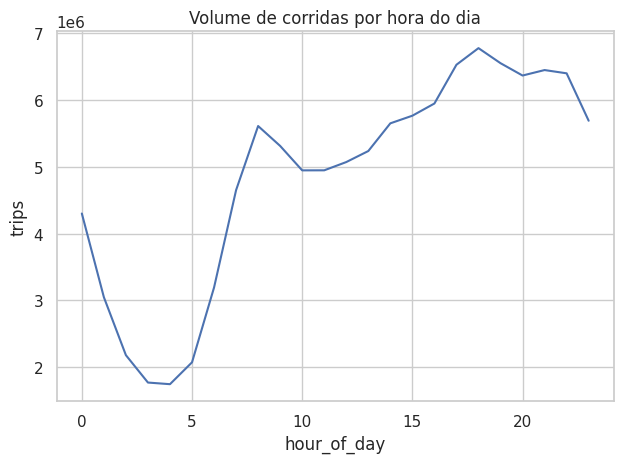

In [6]:
# Volume por hora do dia
hourly_pdf = spark.sql("""
SELECT hour_of_day, COUNT(*) AS trips
FROM trips_bronze
GROUP BY 1 ORDER BY 1
""").toPandas()

ax = sns.lineplot(data=hourly_pdf, x='hour_of_day', y='trips')
ax.set_title('Volume de corridas por hora do dia')
ax.figure.tight_layout()
plt.show()


In [7]:
# Top 10 zonas de embarque (excluindo Unknown 264/265)
top_pickups_pdf = spark.sql("""
SELECT
    z.Zone, z.Borough, COUNT(*) AS trips
FROM trips_bronze t
LEFT JOIN taxi_zone_lookup z ON t.pickup_location = z.LocationID
WHERE t.pickup_location NOT IN (264, 265)
GROUP BY z.Zone, z.Borough
ORDER BY trips DESC
LIMIT 10
""").toPandas()
print(top_pickups_pdf.to_string(index=False))


                     Zone   Borough   trips
              JFK Airport    Queens 2254657
        LaGuardia Airport    Queens 2237090
             East Village Manhattan 1632149
      Crown Heights North  Brooklyn 1531409
           Midtown Center Manhattan 1457938
Times Sq/Theatre District Manhattan 1450370
     TriBeCa/Civic Center Manhattan 1350337
             East Chelsea Manhattan 1338815
            Midtown South Manhattan 1291369
West Chelsea/Hudson Yards Manhattan 1280985


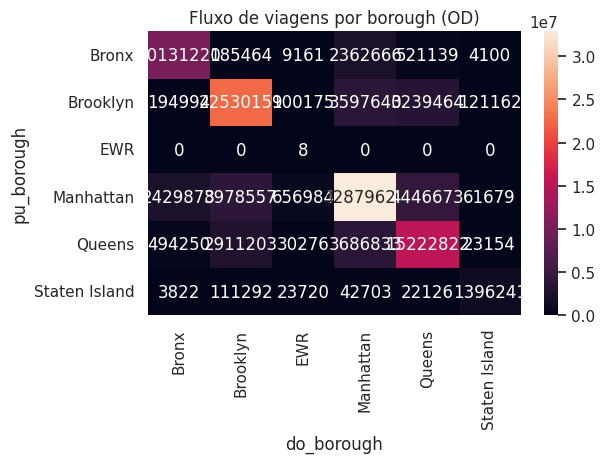

In [8]:
# Matriz OD por borough
borough_od_pdf = spark.sql("""
SELECT
    pu.Borough AS pu_borough,
    do.Borough AS do_borough,
    COUNT(*) AS trips
FROM trips_bronze t
LEFT JOIN taxi_zone_lookup pu ON t.pickup_location  = pu.LocationID
LEFT JOIN taxi_zone_lookup do ON t.dropoff_location = do.LocationID
WHERE t.pickup_location  NOT IN (264, 265)
  AND t.dropoff_location NOT IN (264, 265)
GROUP BY 1, 2
ORDER BY 3 DESC
""").toPandas()

pivot = borough_od_pdf.pivot(index='pu_borough', columns='do_borough', values='trips').fillna(0)
sns.heatmap(pivot, fmt='.0f', annot=True)
plt.title('Fluxo de viagens por borough (OD)')
plt.tight_layout()
plt.show()


In [9]:
# Correlacao das features numericas com o target
spark.sql("""
SELECT
    ROUND(corr(trip_length,     passenger_fare), 4) AS corr_miles_fare,
    ROUND(corr(total_ride_time, passenger_fare), 4) AS corr_time_fare,
    ROUND(corr(request_to_pickup, passenger_fare), 4) AS corr_wait_fare,
    ROUND(corr(hour_of_day,     passenger_fare), 4) AS corr_hour_fare,
    ROUND(corr(driver_total_pay, passenger_fare), 4) AS corr_driver_fare
FROM trips_bronze
WHERE passenger_fare > 0
""").show()
# Nota: corr(driver_total_pay, fare) alto e esperado (regulatorio), nao usar driver_total_pay como feature.


+---------------+--------------+--------------+--------------+----------------+
|corr_miles_fare|corr_time_fare|corr_wait_fare|corr_hour_fare|corr_driver_fare|
+---------------+--------------+--------------+--------------+----------------+
|         0.8785|        0.8216|         0.048|        0.0047|          0.9523|
+---------------+--------------+--------------+--------------+----------------+



## Observacoes EDA

- Dataset cobre apenas Uber e Lyft (sem Juno/Via).
- `hourly_rate` e `dollars_per_mile` sao derivadas de `passenger_fare` — excluidas do silver.
- `driver_total_pay` tem correlacao alta com o target por ser regulatorio (TLC LL150/2018) — excluido das features.
- Zonas 264 e 265 (Unknown/Outside NYC) excluidas das analises geograficas.


In [10]:
spark.stop()
